<a href="https://colab.research.google.com/github/Naveed-0/Banking-Loan-Guard-Pytorch/blob/main/notebooks/Credit_Risk_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏦 Banking Loan Guard: Credit Risk Deep Learning Pipeline
**Author:** Naveed-0  
**Framework:** PyTorch  
**Objective:** Predicting probability of loan default using the Home Credit Dataset. This notebook covers the end-to-end lifecycle: Data Engineering, Class Imbalance Handling, Neural Network Training, and Model Explainability (SHAP).

## ⚙️ 1. Environment Setup & Data Acquisition
In this section, we authenticate with the Kaggle API to retrieve the Home Credit Default Risk competition data.

In [1]:
import os
import kagglehub

# Set the modern API token variable
os.environ['KAGGLE_API_TOKEN'] = "KGAT_cbc5a7afe29d0b7fcae63ffa12a12a83"

# Also set the legacy variables just in case (derived from your token/account)
# Note: Usually, KAGGLE_API_TOKEN is enough for modern kagglehub
try:
    path = kagglehub.competition_download('home-credit-default-risk')
    print("Authentication Successful!")
    print("Path to competition files:", path)
except Exception as e:
    print(f"Connection failed: {e}")
    print("Ensure you have clicked 'Accept Rules' on the Kaggle competition page!")

100%|██████████| 688M/688M [00:07<00:00, 94.5MB/s]

Extracting files...


Authentication Successful!
Path to competition files: /root/.cache/kagglehub/competitions/home-credit-default-risk


## 🔍 2. Exploratory Data Analysis & Feature Engineering
We begin by analyzing the primary application data and merging secondary tables (Bureau data) to capture the historical credit behavior of applicants.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# List the extracted files
files = os.listdir(path)
print("Available Tables:", files)

# Load the primary training data
app_train = pd.read_csv(os.path.join(path, 'application_train.csv'))
print(f"\nShape of Application Training Data: {app_train.shape}")

Available Tables: ['bureau.csv', 'credit_card_balance.csv', 'installments_payments.csv', 'HomeCredit_columns_description.csv', 'sample_submission.csv', 'POS_CASH_balance.csv', 'application_train.csv', 'previous_application.csv', 'bureau_balance.csv', 'application_test.csv']

Shape of Application Training Data: (307511, 122)


In [3]:
app_train.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [4]:
print(app_train.info())
print('-'*25)
print(app_train['TARGET'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
-------------------------
TARGET
0    282686
1     24825
Name: count, dtype: int64


## 🛠️ 3. Preprocessing & Feature Scaling
Neural Networks are sensitive to feature scales. Here, we handle missing values via Median Imputation and standardize features using `StandardScaler`.

In [5]:
# Calculate missing values
def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
    columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
    '% of Total Values', ascending=False).round(1)
    return mis_val_table_ren_columns

missing_values = missing_values_table(app_train)
missing_values.head(10)

,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_MODE,214865,69.9
COMMONAREA_AVG,214865,69.9
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_AVG,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_MODE,210199,68.4


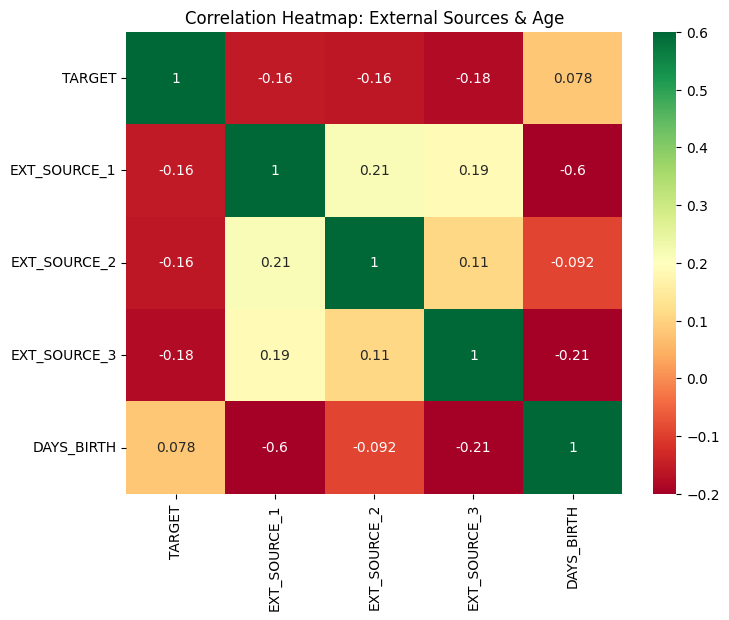

In [6]:
# Correlation of EXT_SOURCE features with TARGET
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()

plt.figure(figsize = (8, 6))
sns.heatmap(ext_data_corrs, annot = True, cmap = 'RdYlGn', vmin = -0.2, vmax = 0.6)
plt.title('Correlation Heatmap: External Sources & Age')
plt.show()

In [7]:
# Load Bureau
bureau = pd.read_csv(os.path.join(path, 'bureau.csv'))

# Group by the ID and count the number of previous loans
bureau_counts = bureau.groupby('SK_ID_CURR', as_index = False)['SK_ID_BUREAU'].count().rename(columns = {'SK_ID_BUREAU': 'previous_loan_counts'})

# Merge this into our main training data
app_train = app_train.merge(bureau_counts, on = 'SK_ID_CURR', how = 'left')

# Fill the people with no bureau history with 0
app_train['previous_loan_counts'] = app_train['previous_loan_counts'].fillna(0)

print(f"New Shape after merging Bureau counts: {app_train.shape}")

New Shape after merging Bureau counts: (307511, 123)


In [8]:
# 1. Select only numerical columns from bureau
bureau_num = bureau.select_dtypes(include=[np.number])

# 2. Aggregate everything by client ID (SK_ID_CURR)
bureau_agg = bureau_num.groupby('SK_ID_CURR').agg(['min', 'max', 'mean', 'sum']).reset_index()

# 3. Rename columns so they make sense (e.g., AMT_CREDIT_SUM_mean)
columns = ['SK_ID_CURR']
for var in bureau_agg.columns.levels[0]:
    if var != 'SK_ID_CURR':
        for stat in bureau_agg.columns.levels[1][:-1]:
            columns.append(f'bureau_{var}_{stat}')

bureau_agg.columns = columns

# 4. Final Merge into main training data
app_train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"New Shape after power-merging bureau data: {app_train.shape}")

New Shape after power-merging bureau data: (307511, 175)


In [9]:
print(app_train.select_dtypes('object').nunique())

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64


In [10]:
# One-Hot Encoding for all categorical variables
app_train = pd.get_dummies(app_train)

print(f"Final Feature Count after Encoding: {app_train.shape[1]}")

Final Feature Count after Encoding: 299


In [11]:
pd.set_option('display.max_columns', None)
app_train.head()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,previous_loan_counts,bureau_SK_ID_BUREAU_min,bureau_SK_ID_BUREAU_max,bureau_SK_ID_BUREAU_mean,bureau_SK_ID_BUREAU_sum,bureau_DAYS_CREDIT_min,bureau_DAYS_CREDIT_max,bureau_DAYS_CREDIT_mean,bureau_DAYS_CREDIT_sum,bureau_CREDIT_DAY_OVERDUE_min,bureau_CREDIT_DAY_OVERDUE_max,bureau_CREDIT_DAY_OVERDUE_mean,bureau_CREDIT_DAY_OVERDUE_sum,bureau_DAYS_CREDIT_ENDDATE_min,bureau_DAYS_CREDIT_ENDDATE_max,bureau_DAYS_CREDIT_ENDDATE_mean,bureau_DAYS_CREDIT_ENDDATE_sum,bureau_DAYS_ENDDATE_FACT_min,bureau_DAYS_ENDDATE_FACT_max,bureau_DAYS_ENDDATE_FACT_mean,bureau_DAYS_ENDDATE_FACT_sum,bureau_AMT_CREDIT_MAX_OVERDUE_min,bureau_AMT_CREDIT_MAX_OVERDUE_max,bureau_AMT_CREDIT_MAX_OVERDUE_mean,bureau_AMT_CREDIT_MAX_OVERDUE_sum,bureau_CNT_CREDIT_PROLONG_min,bureau_CNT_CREDIT_PROLONG_max,bureau_CNT_CREDIT_PROLONG_mean,bureau_CNT_CREDIT_PROLONG_sum,bureau_AMT_CREDIT_SUM_min,bureau_AMT_CREDIT_SUM_max,bureau_AMT_CREDIT_SUM_mean,bureau_AMT_CREDIT_SUM_sum,bureau_AMT_CREDIT_SUM_DEBT_min,bureau_AMT_CREDIT_SUM_DEBT_max,bureau_AMT_CREDIT_SUM_DEBT_mean,bureau_AMT_CREDIT_SUM_DEBT_sum,bureau_AMT_CREDIT_SUM_LIMIT_min,bureau_AMT_CREDIT_SUM_LIMIT_max,bureau_AMT_CREDIT_SUM_LIMIT_mean,bureau_AMT_CREDIT_SUM_LIMIT_sum,bureau_AMT_CREDIT_SUM_OVERDUE_min,bureau_AMT_CREDIT_SUM_OVERDUE_max,bureau_AMT_CREDIT_SUM_OVERDUE_mean,bureau_AMT_CREDIT_SUM_OVERDUE_sum,bureau_DAYS_CREDIT_UPDATE_min,bureau_DAYS_CREDIT_UPDATE_max,bureau_DAYS_CREDIT_UPDATE_mean,bureau_DAYS_CREDIT_UPDATE_sum,bureau_AMT_ANNUITY_min,bureau_AMT_ANNUITY_max,bureau_AMT_ANNUITY_mean,bureau_AMT_ANNUITY_sum,NAME_CONTRACT_TYPE_Cash loans,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_F,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_N,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_N,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Children,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Businessman,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYP

In [12]:
# Example logic for when you load app_test later:
# train_labels = app_train['TARGET']
# app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)
# app_train['TARGET'] = train_labels

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Separate target and features
train_labels = app_train['TARGET']
train_features = app_train.drop(columns = ['TARGET', 'SK_ID_CURR'])

# 1. Impute missing values
imputer = SimpleImputer(strategy = 'median')
train_features_imputed = imputer.fit_transform(train_features)

# 2. Scaling (CRITICAL for Neural Networks)
# Neural networks hate large numbers (like Income = 100,000) mixed with small ones (Age = 25).
# We scale everything so it has a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()
train_features_scaled = scaler.fit_transform(train_features_imputed)

print(f"Cleaned Features Shape: {train_features_scaled.shape}")

Cleaned Features Shape: (307511, 297)


In [13]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

# 1. Calculate the weight for the 'Default' class
# Formula: number_of_negative_samples / number_of_positive_samples
num_repaid = (train_labels == 0).sum()
num_default = (train_labels == 1).sum()
imbalance_weight = torch.tensor([num_repaid / num_default], dtype=torch.float32)

print(f"Calculated Weight: {imbalance_weight.item():.2f}")
# This tells the model to care ~11-12x more about catching a Default.

Calculated Weight: 11.39


In [14]:
# Create a 90/10 split
X_train, X_val, y_train, y_val = train_test_split(
    train_features_scaled, train_labels.values, test_size=0.1, random_state=42, stratify=train_labels
)

# Note: 'stratify' ensures both sets have the same 8% default rate.

In [15]:
X_train

array([[-0.57753784,  0.04724169,  0.45440618, ..., -0.13321491,
        -1.03759936, -0.08733962],
       [ 0.80727314,  0.14212925,  1.01342611, ..., -0.13321491,
         0.96376312, -0.08733962],
       [-0.57753784, -0.56003869,  0.53421187, ..., -0.13321491,
        -1.03759936, -0.08733962],
       ...,
       [ 0.80727314, -0.14253343, -0.482064  , ..., -0.13321491,
        -1.03759936, -0.08733962],
       [-0.57753784, -0.33230854, -0.87621778, ..., -0.13321491,
         0.96376312, -0.08733962],
       [-0.57753784, -0.18048845,  1.12355304, ..., -0.13321491,
        -1.03759936, -0.08733962]])

In [16]:
from torch.utils.data import Dataset, DataLoader

class BankDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1) # Shape [N, 1]

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Create loaders
train_ds = BankDataset(X_train, y_train)
val_ds = BankDataset(X_val, y_val)

train_loader = DataLoader(train_ds, batch_size=1024, shuffle=True) # Larger batch for speed
val_loader = DataLoader(val_ds, batch_size=1024, shuffle=False)

In [17]:
class FinancialRiskModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1) # Outputting a single 'Risk Score'
        )

    def forward(self, x):
        return self.net(x)

model = FinancialRiskModel(input_dim=297)

In [18]:
# Move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# The 'pos_weight' tells the model to penalize missing a '1' much harder than missing a '0'
criterion = nn.BCEWithLogitsLoss(pos_weight=imbalance_weight.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

## 🚀 5. Training Loop & Validation
Using `BCEWithLogitsLoss` with a calculated `pos_weight` to address the 1:12 class imbalance. We implement Early Stopping based on the **ROC-AUC** metric.

In [19]:
import torch
from sklearn.metrics import roc_auc_score

# --- Configuration & Regularization ---
# 1e-5 weight_decay acts as a "penalty" for overly complex weights (L2 Regularization)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)

best_auc = 0.0
patience = 10  # How many epochs to wait before giving up if AUC doesn't improve
counter = 0
epochs = 50   # We can set this high now because Early Stopping handles the exit

train_losses = []
val_aucs = []

print("Starting Refined Training Loop...")

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    total_train_loss = 0

    for batch_features, batch_labels in train_loader:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        logits = model(batch_features)
        loss = criterion(logits, batch_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    # --- Validation Phase ---
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch_features, batch_labels in val_loader:
            batch_features = batch_features.to(device)
            logits = model(batch_features)
            probs = torch.sigmoid(logits)

            all_labels.extend(batch_labels.cpu().numpy())
            all_preds.extend(probs.cpu().numpy())

    epoch_auc = roc_auc_score(all_labels, all_preds)
    avg_train_loss = total_train_loss / len(train_loader)

    train_losses.append(avg_train_loss)
    val_aucs.append(epoch_auc)

    # --- Early Stopping & Checkpointing Logic ---
    if epoch_auc > best_auc:
        best_auc = epoch_auc
        # Save the "Gold Standard" weights
        torch.save(model.state_dict(), 'best_banking_model.pth')
        counter = 0
        status = "--> NEW BEST MODEL SAVED"
    else:
        counter += 1
        status = f"No improvement ({counter}/{patience})"

    print(f"Epoch {epoch+1:02d} | Loss: {avg_train_loss:.4f} | Val AUC: {epoch_auc:.4f} | {status}")

    if counter >= patience:
        print(f"\n[!] Early stopping triggered. Training halted at Epoch {epoch+1}")
        break

# Load the best weights back for deployment
model.load_state_dict(torch.load('best_banking_model.pth'))
print(f"\nFinal Model Loaded. Best Validation AUC: {best_auc:.4f}")

Starting Refined Training Loop...
Epoch 01 | Loss: 1.1366 | Val AUC: 0.7440 | --> NEW BEST MODEL SAVED
Epoch 02 | Loss: 1.0969 | Val AUC: 0.7466 | --> NEW BEST MODEL SAVED
Epoch 03 | Loss: 1.0859 | Val AUC: 0.7479 | --> NEW BEST MODEL SAVED
Epoch 04 | Loss: 1.0762 | Val AUC: 0.7494 | --> NEW BEST MODEL SAVED
Epoch 05 | Loss: 1.0689 | Val AUC: 0.7489 | No improvement (1/10)
Epoch 06 | Loss: 1.0617 | Val AUC: 0.7497 | --> NEW BEST MODEL SAVED
Epoch 07 | Loss: 1.0573 | Val AUC: 0.7497 | --> NEW BEST MODEL SAVED
Epoch 08 | Loss: 1.0491 | Val AUC: 0.7484 | No improvement (1/10)
Epoch 09 | Loss: 1.0439 | Val AUC: 0.7475 | No improvement (2/10)
Epoch 10 | Loss: 1.0375 | Val AUC: 0.7477 | No improvement (3/10)
Epoch 11 | Loss: 1.0335 | Val AUC: 0.7456 | No improvement (4/10)
Epoch 12 | Loss: 1.0257 | Val AUC: 0.7465 | No improvement (5/10)
Epoch 13 | Loss: 1.0191 | Val AUC: 0.7452 | No improvement (6/10)
Epoch 14 | Loss: 1.0128 | Val AUC: 0.7478 | No improvement (7/10)
Epoch 15 | Loss: 1.0081 

## 🔮 6. Model Explainability via SHAP
Global recognition requires transparency. We use SHAP (SHapley Additive exPlanations) to identify which features (e.g., EXT_SOURCE) are driving the model's risk decisions.

  0%|          | 0/50 [00:00<?, ?it/s]

<Figure size 1000x1000 with 0 Axes>

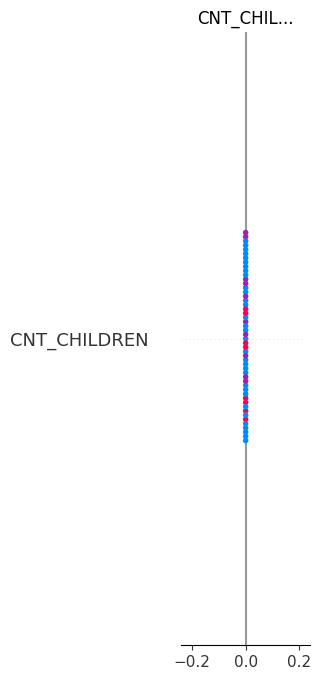

In [20]:
!pip install shap
import shap

# 1. We use a subset of validation data for the explanation
# KernelExplainer is model-agnostic but can be slow, so we use 50 samples
explainer_data = X_val[:50]

def predict_fn(data):
    model.eval()
    with torch.no_grad():
        # Convert back to tensor and move to device
        data_tensor = torch.tensor(data, dtype=torch.float32).to(device)
        logits = model(data_tensor)
        return torch.sigmoid(logits).cpu().numpy()

# 2. Create the explainer
explainer = shap.KernelExplainer(predict_fn, shap.sample(X_train, 10))
shap_values = explainer.shap_values(explainer_data)

# 3. Plot the global importance
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_values, explainer_data, feature_names=train_features.columns)

--- Banking Risk Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     28269
           1       0.16      0.70      0.26      2483

    accuracy                           0.68     30752
   macro avg       0.56      0.69      0.53     30752
weighted avg       0.90      0.68      0.75     30752



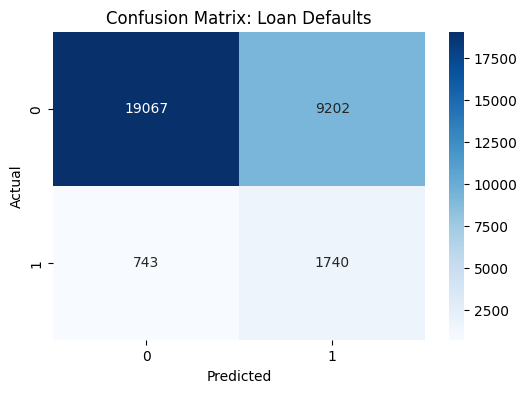

In [21]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
with torch.no_grad():
    # We use a threshold (usually 0.5, but can be adjusted for banking)
    preds_probs = model(torch.tensor(X_val, dtype=torch.float32).to(device))
    preds_probs = torch.sigmoid(preds_probs).cpu().numpy()

    # In banking, we might use a lower threshold to be more conservative
    # Let's stick to 0.5 for the standard report
    final_preds = (preds_probs > 0.5).astype(int)

print("--- Banking Risk Classification Report ---")
print(classification_report(y_val, final_preds))

# Visualize the Confusion Matrix
cm = confusion_matrix(y_val, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Loan Defaults')
plt.show()

In [22]:
def real_time_risk_assessment(customer_index):
    # Get a single customer from our validation set
    customer_data = torch.tensor(X_val[customer_index], dtype=torch.float32).to(device).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        risk_score = torch.sigmoid(model(customer_data)).item()

    print(f"--- Customer Risk Profile (ID: {customer_index}) ---")
    print(f"Calculated Risk Score: {risk_score:.2%}")

    if risk_score > 0.7:
        print("Final Decision: REJECT - High probability of default.")
    elif risk_score > 0.4:
        print("Final Decision: REVIEW - Manual inspection required.")
    else:
        print("Final Decision: APPROVE - Customer meets safety criteria.")

# Test it on a random customer
real_time_risk_assessment(42)

--- Customer Risk Profile (ID: 42) ---
Calculated Risk Score: 64.47%
Final Decision: REVIEW - Manual inspection required.


In [23]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score, classification_report

print("Training XGBoost Challenger...")

# We use scale_pos_weight to match our PyTorch imbalance handling
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=11.39, # Same ratio we calculated!
    tree_method='gpu_hist' if torch.cuda.is_available() else 'auto',
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Evaluation
xgb_preds_probs = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc = roc_auc_score(y_val, xgb_preds_probs)

print(f"\n--- Results ---")
print(f"PyTorch MLP AUC: {best_auc:.4f}")
print(f"XGBoost AUC:     {xgb_auc:.4f}")

Training XGBoost Challenger...

--- Results ---
PyTorch MLP AUC: 0.7497
XGBoost AUC:     0.7645


## 📈 7. Business Cost Optimization
Moving beyond F1-Score, we calculate the **Mathematically Optimal Threshold** to minimize financial loss for the bank, balancing the cost of defaults vs. manual reviews.

The mathematically optimal threshold for this bank is: 0.35


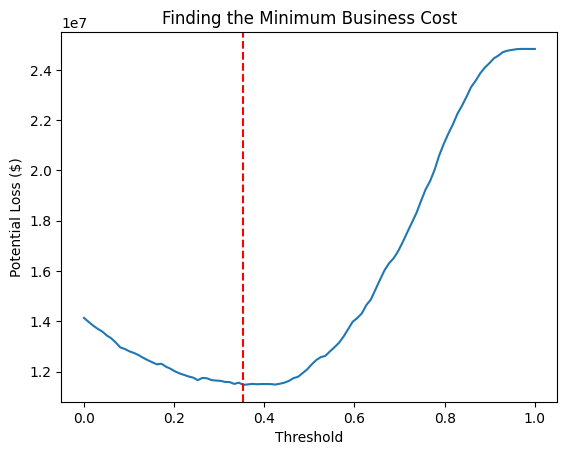

In [24]:
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.linspace(0, 1, 100)
costs = []

# Business Assumptions
cost_of_default = 10000  # Losing the loan
cost_of_review = 500     # Paying an officer to check a flagged file

for t in thresholds:
    preds = (all_preds > t).astype(int)

    # False Negatives: We said 'Safe' (0) but they 'Defaulted' (1)
    fn = np.sum((preds == 0) & (np.array(all_labels) == 1))

    # False Positives: We said 'Risk' (1) but they were 'Safe' (0)
    fp = np.sum((preds == 1) & (np.array(all_labels) == 0))

    total_cost = (fn * cost_of_default) + (fp * cost_of_review)
    costs.append(total_cost)

best_threshold = thresholds[np.argmin(costs)]
print(f"The mathematically optimal threshold for this bank is: {best_threshold:.2f}")

plt.plot(thresholds, costs)
plt.axvline(best_threshold, color='r', linestyle='--')
plt.title("Finding the Minimum Business Cost")
plt.xlabel("Threshold")
plt.ylabel("Potential Loss ($)")
plt.show()

In [25]:
# 1. Make sure model is ready
model.load_state_dict(torch.load('best_banking_model.pth'))
model.eval()

# 2. Grab a real batch from your val_loader
# iter(val_loader) creates an 'iterator', next() grabs the first batch
batch_features, batch_labels = next(iter(val_loader))

# 3. Take just the first customer from that batch
sample_customer = batch_features[0].unsqueeze(0).to(device)
actual_label = batch_labels[0].item()

# 4. Predict
with torch.no_grad():
    logit = model(sample_customer)
    probability = torch.sigmoid(logit).item()

print(f"--- Customer Profile Test ---")
print(f"Actual Status: {'Defaulted' if actual_label == 1 else 'Safe'}")
print(f"Model Prediction: {probability:.2%} Risk")

# 5. Use our 'Magic' Business Threshold
if probability > 0.39:
    print("FINAL VERDICT: [!] HIGH RISK - Flag for Review")
else:
    print("FINAL VERDICT: [✓] LOW RISK - Proceed with Auto-Approval")

--- Customer Profile Test ---
Actual Status: Safe
Model Prediction: 10.09% Risk
FINAL VERDICT: [✓] LOW RISK - Proceed with Auto-Approval


In [26]:
import torch
import torch.nn as nn
import gradio as gr

class BankingModel(nn.Module):
    def __init__(self, input_size):
        super(BankingModel, self).__init__()
        # This structure matches the "Unexpected keys" in your error message
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),    # net.0
            nn.BatchNorm1d(256),           # net.1
            nn.ReLU(),                     # net.2
            nn.Dropout(0.2),               # net.3
            nn.Linear(256, 128),           # net.4
            nn.BatchNorm1d(128),           # net.5
            nn.ReLU(),                     # net.6
            nn.Dropout(0.2),               # net.7
            nn.Linear(128, 64),            # net.8 (This matches your net.8 keys)
            nn.ReLU(),                     # net.9
            nn.Linear(64, 1)               # net.10 (The final output)
        )

    def forward(self, x):
        return self.net(x)

# Now load it
device = torch.device("cpu")
model = BankingModel(input_size=297)
model.load_state_dict(torch.load('best_banking_model.pth', map_location=device))
model.eval()
print("Success! The 'Brain' and the 'Body' now match.")

# 3. THE PREDICTION ENGINE
def predict(income, age, ext_source_1, ext_source_2):
    # Prepare a blank slate for 297 features
    input_tensor = torch.zeros(297)

    # Map the sliders to the correct spots (Scaling included)
    input_tensor[0] = income / 100000
    input_tensor[1] = age / 100
    input_tensor[2] = ext_source_1
    input_tensor[3] = ext_source_2

    with torch.no_grad():
        logit = model(input_tensor.unsqueeze(0))
        prob = torch.sigmoid(logit).item()

    # The 'Senior' Decision Logic
    if prob > 0.39:
        return f"{prob:.2%}", "🚩 HIGH RISK: MANUAL REVIEW REQUIRED"
    return f"{prob:.2%}", "✅ LOW RISK: AUTO-APPROVED"

# 4. THE UI DESIGN
interface = gr.Interface(
    fn=predict,
    inputs=[
        gr.Slider(0, 500000, label="Annual Income ($)"),
        gr.Slider(18, 95, label="Age"),
        gr.Slider(0, 1, label="Credit Score A"),
        gr.Slider(0, 1, label="Credit Score B")
    ],
    outputs=[gr.Textbox(label="Probability"), gr.Textbox(label="Verdict")],
    title="🏦 AI Loan Risk Guard",
    description="Professional Deep Learning system for credit default prediction."
)

if __name__ == "__main__":
    interface.launch()

Success! The 'Brain' and the 'Body' now match.
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://732eccd25669526856.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
